In [1]:
import importlib
import torch
import pandas as pd
import model_code.hidden_state_analysis as analysis
# import model_code.steering_extraction as steering_extraction
# from model_code.steering_extraction import  generateSteering, retrieve_steering_vector

importlib.reload(analysis)
# importlib.reload(steering_extraction)

<module 'model_code.hidden_state_analysis' from '/workspace/Dissertation_Project/model_code/hidden_state_analysis.py'>

In [2]:
emotion_vector_eng = torch.load("resources/saved_vectors/English Vectors/emotion_vectors.pt")
emotion_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors/emotion_vectors.pt")

steering_vector_eng = torch.load("resources/saved_vectors/English Vectors/steering_vectors.pt")
steering_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors/steering_vectors.pt")

/tmp/ipykernel_14022/3013748282.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  emotion_vector_eng = torch.load("resources/saved_vectors/English Vectors/emotion_vectors.

# Probing across different emotion across languages

## Binary Probe 

In [4]:
all_emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']

emotion_probe = {
    'anger': 'anger',
    'happiness': 'happiness',
    'sadness': 'sadness',
    'love': 'love',
    'fear': 'fear'
}

result_stored = {}

for emotion in all_emotions:
    # 4096 input => 1 output, binary classification
    probe = analysis.LogisticRegressionProbe(input_dim=emotion_vector_eng[emotion][0].shape[-1], output_dim=1)
    # Dataloader 
    emotion_data_eng_train, emotion_data_eng_val = analysis.create_dataloader(emotion_vector_eng, emotion=emotion,val_ratio=0.4)
    emotion_data_id_train, emotion_data_id_val = analysis.create_dataloader(emotion_vector_id, emotion=emotion,val_ratio=0.4)
    # Trianing the probe
    emotion_probe[emotion] = analysis.trainProbe(probe, emotion_data_eng_train, emotion_data_eng_val)
    result_stored[emotion] = {}
    result_stored[emotion]["indonesian"] = analysis.predictProbe(emotion_probe[emotion], emotion_data_id_val)
    result_stored[emotion]["english"] = analysis.predictProbe(emotion_probe[emotion], emotion_data_eng_val)


/workspace/Dissertation_Project/model_code/hidden_state_analysis.py:139: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  X = torch.tensor(correct_vectors + incorrect_vectors, dtype=torch.float32)


Epoch 1/10, Loss: 0.6888
Validation Accuracy: 0.5125
Epoch 2/10, Loss: 0.6594
Validation Accuracy: 0.5563
Epoch 3/10, Loss: 0.6310
Validation Accuracy: 0.7562
Epoch 4/10, Loss: 0.6115
Validation Accuracy: 0.7875
Epoch 5/10, Loss: 0.5922
Validation Accuracy: 0.7937
Epoch 6/10, Loss: 0.5828
Validation Accuracy: 0.7656
Epoch 7/10, Loss: 0.5773
Validation Accuracy: 0.7469
Epoch 8/10, Loss: 0.5594
Validation Accuracy: 0.7844
Epoch 9/10, Loss: 0.5406
Validation Accuracy: 0.7781
Epoch 10/10, Loss: 0.5274
Validation Accuracy: 0.8125
Epoch 1/10, Loss: 0.6944
Validation Accuracy: 0.5125
Epoch 2/10, Loss: 0.6679
Validation Accuracy: 0.5969
Epoch 3/10, Loss: 0.6392
Validation Accuracy: 0.7250
Epoch 4/10, Loss: 0.6181
Validation Accuracy: 0.7406
Epoch 5/10, Loss: 0.6028
Validation Accuracy: 0.7438
Epoch 6/10, Loss: 0.5881
Validation Accuracy: 0.7406
Epoch 7/10, Loss: 0.5734
Validation Accuracy: 0.7344
Epoch 8/10, Loss: 0.5596
Validation Accuracy: 0.7844
Epoch 9/10, Loss: 0.5528
Validation Accuracy:

In [7]:
emotion_data_id_train, emotion_data_id_val = analysis.create_dataloader(emotion_vector_id, emotion='happiness',val_ratio=0.4)
emotion_data_eng_train, emotion_data_eng_val = analysis.create_dataloader(emotion_vector_eng, emotion='happiness',val_ratio=0.4)
trial = analysis.predictProbe(emotion_probe['sadness'], emotion_data_eng_val)
trial 

array([0.40625, 0.46875, 0.40625, 0.28125, 0.46875, 0.28125, 0.34375,
       0.5    , 0.40625, 0.53125])

In [6]:
# Summary table from the loop above
summary_rows = []
for emotion, lang_scores in result_stored.items():
    id_scores = lang_scores["indonesian"]
    en_scores = lang_scores["english"]
    summary_rows.append({
        "emotion": emotion,
        "indonesian_mean_acc": float(id_scores.mean()),
        "english_mean_acc": float(en_scores.mean()),
        "num_eval_batches_id": len(id_scores),
        "num_eval_batches_en": len(en_scores),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("emotion").reset_index(drop=True)
display(summary_df)

,emotion,indonesian_mean_acc,english_mean_acc,num_eval_batches_id,num_eval_batches_en
0,anger,0.762500,0.812500,10,10
1,fear,0.750000,0.793750,10,10
2,happiness,0.775000,0.768750,10,10
3,love,0.818750,0.815625,10,10
4,sadness,0.771875,0.728125,10,10


## Multi-Class Probe 

In [10]:
all_emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']

result_stored = {}

# Single multiclass probe (not one-vs-rest)
probe = analysis.LogisticRegressionProbe(
    input_dim=emotion_vector_eng[all_emotions[0]][0].shape[-1],
    output_dim=len(all_emotions),
)

# Build multiclass datasets using the same class order on both languages
emotion_data_eng_train, emotion_data_eng_val = analysis.create_dataloader(
    emotion_vector_eng,
    emotion=all_emotions[0],
    val_ratio=0.4,
    multiclass=True,
    multiclass_emotions=all_emotions,
)
emotion_data_id_train, emotion_data_id_val = analysis.create_dataloader(
    emotion_vector_id,
    emotion=all_emotions[0],
    val_ratio=0.4,
    multiclass=True,
    multiclass_emotions=all_emotions,
)

probe = analysis.trainMultiClassProbe(probe, emotion_data_eng_train, emotion_data_eng_val, num_epochs=25)

result_stored['multiclass'] = {}
result_stored['multiclass']['indonesian'] = analysis.predictProbe(
    probe,
    emotion_data_id_val,
    multiclass=True,
)
result_stored['multiclass']['english'] = analysis.predictProbe(
    probe,
    emotion_data_eng_val,
    multiclass=True,
)

print('Multiclass mean batch accuracy (EN):', float(result_stored['multiclass']['english'].mean()))
print('Multiclass mean batch accuracy (ID):', float(result_stored['multiclass']['indonesian'].mean()))

Epoch 1/25, Loss: 1.5497
Validation Accuracy: 0.4387
Epoch 2/25, Loss: 1.3846
Validation Accuracy: 0.5625
Epoch 3/25, Loss: 1.2728
Validation Accuracy: 0.5650
Epoch 4/25, Loss: 1.1775
Validation Accuracy: 0.6225
Epoch 5/25, Loss: 1.0993
Validation Accuracy: 0.6500
Epoch 6/25, Loss: 1.0267
Validation Accuracy: 0.6162
Epoch 7/25, Loss: 0.9811
Validation Accuracy: 0.6300
Epoch 8/25, Loss: 0.9363
Validation Accuracy: 0.6562
Epoch 9/25, Loss: 0.8990
Validation Accuracy: 0.6600
Epoch 10/25, Loss: 0.8610
Validation Accuracy: 0.6663
Epoch 11/25, Loss: 0.8279
Validation Accuracy: 0.6650
Epoch 12/25, Loss: 0.8094
Validation Accuracy: 0.6575
Epoch 13/25, Loss: 0.7742
Validation Accuracy: 0.6500
Epoch 14/25, Loss: 0.7518
Validation Accuracy: 0.6550
Epoch 15/25, Loss: 0.7307
Validation Accuracy: 0.6650
Epoch 16/25, Loss: 0.7093
Validation Accuracy: 0.6763
Epoch 17/25, Loss: 0.6881
Validation Accuracy: 0.6737
Epoch 18/25, Loss: 0.6707
Validation Accuracy: 0.6750
Epoch 19/25, Loss: 0.6549
Validation 

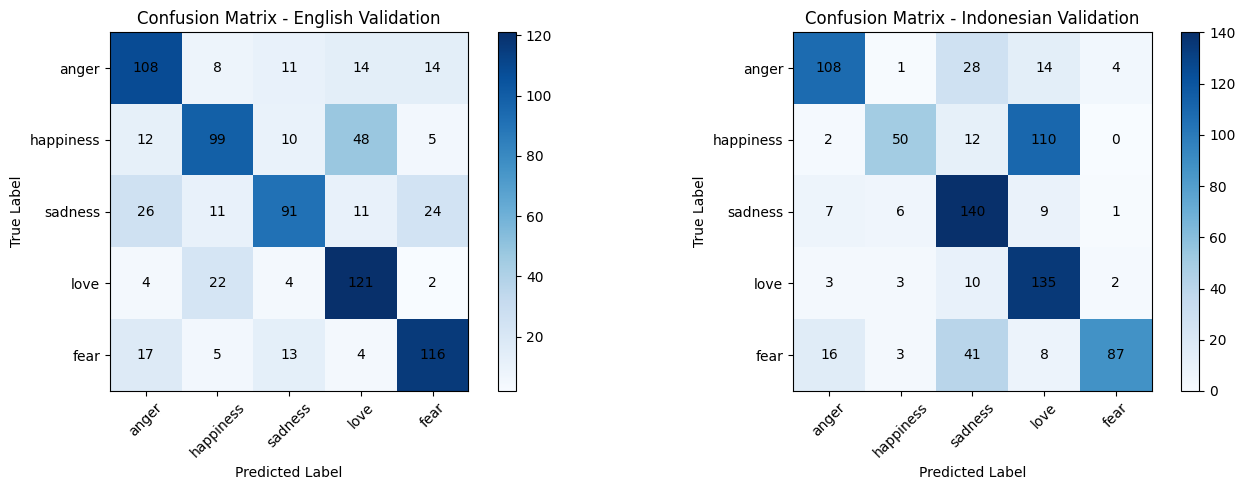

ENGLISH VALIDATION SET
              precision    recall  f1-score   support

       anger       0.65      0.70      0.67       155
   happiness       0.68      0.57      0.62       174
     sadness       0.71      0.56      0.62       163
        love       0.61      0.79      0.69       153
        fear       0.72      0.75      0.73       155

    accuracy                           0.67       800
   macro avg       0.67      0.67      0.67       800
weighted avg       0.67      0.67      0.67       800

INDONESIAN VALIDATION SET
              precision    recall  f1-score   support

       anger       0.79      0.70      0.74       155
   happiness       0.79      0.29      0.42       174
     sadness       0.61      0.86      0.71       163
        love       0.49      0.88      0.63       153
        fear       0.93      0.56      0.70       155

    accuracy                           0.65       800
   macro avg       0.72      0.66      0.64       800
weighted avg       0.72     

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import torch

# Collect all predictions and true labels for EN validation set
all_preds_en = []
all_labels_en = []
with torch.no_grad():
    for X_batch, y_batch in emotion_data_eng_val:
        X_batch = X_batch.to(next(probe.parameters()).device)
        outputs = probe(X_batch)
        predicted = torch.argmax(outputs, dim=1)
        all_preds_en.extend(predicted.cpu().numpy())
        all_labels_en.extend(y_batch.numpy())

# Collect all predictions and true labels for ID validation set
all_preds_id = []
all_labels_id = []
with torch.no_grad():
    for X_batch, y_batch in emotion_data_id_val:
        X_batch = X_batch.to(next(probe.parameters()).device)
        outputs = probe(X_batch)
        predicted = torch.argmax(outputs, dim=1)
        all_preds_id.extend(predicted.cpu().numpy())
        all_labels_id.extend(y_batch.numpy())

# Compute confusion matrices
cm_en = confusion_matrix(all_labels_en, all_preds_en, labels=range(len(all_emotions)))
cm_id = confusion_matrix(all_labels_id, all_preds_id, labels=range(len(all_emotions)))

# Visualize side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# English confusion matrix
im_en = axes[0].imshow(cm_en, cmap='Blues')
axes[0].set_xticks(range(len(all_emotions)))
axes[0].set_yticks(range(len(all_emotions)))
axes[0].set_xticklabels(all_emotions, rotation=45)
axes[0].set_yticklabels(all_emotions)
axes[0].set_title('Confusion Matrix - English Validation')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
# Add annotations
for i in range(len(all_emotions)):
    for j in range(len(all_emotions)):
        axes[0].text(j, i, str(cm_en[i, j]), ha='center', va='center', color='black', fontsize=10)
plt.colorbar(im_en, ax=axes[0])

# Indonesian confusion matrix
im_id = axes[1].imshow(cm_id, cmap='Blues')
axes[1].set_xticks(range(len(all_emotions)))
axes[1].set_yticks(range(len(all_emotions)))
axes[1].set_xticklabels(all_emotions, rotation=45)
axes[1].set_yticklabels(all_emotions)
axes[1].set_title('Confusion Matrix - Indonesian Validation')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
# Add annotations
for i in range(len(all_emotions)):
    for j in range(len(all_emotions)):
        axes[1].text(j, i, str(cm_id[i, j]), ha='center', va='center', color='black', fontsize=10)
plt.colorbar(im_id, ax=axes[1])

plt.tight_layout()
plt.show()

# Print classification reports
print("=" * 60)
print("ENGLISH VALIDATION SET")
print("=" * 60)
print(classification_report(all_labels_en, all_preds_en, target_names=all_emotions))

print("=" * 60)
print("INDONESIAN VALIDATION SET")
print("=" * 60)
print(classification_report(all_labels_id, all_preds_id, target_names=all_emotions))

# Mantel Test between different steering vectors

,anger,happiness,sadness,love,fear
anger,1.000000,-0.540271,0.150042,-0.606109,0.178716
happiness,-0.540271,1.000000,-0.464207,0.687524,-0.698205
sadness,0.150042,-0.464207,1.000000,-0.549593,0.381912
love,-0.606109,0.687524,-0.549593,1.000000,-0.726445
fear,0.178716,-0.698205,0.381912,-0.726445,1.000000


,anger,happiness,sadness,love,fear
anger,1.000000,0.542532,-0.471628,-0.804029,0.779932
happiness,0.542532,1.000000,-0.558193,-0.876152,0.733189
sadness,-0.471628,-0.558193,1.000000,0.477763,-0.467894
love,-0.804029,-0.876152,0.477763,1.000000,-0.926039
fear,0.779932,0.733189,-0.467894,-0.926039,1.000000


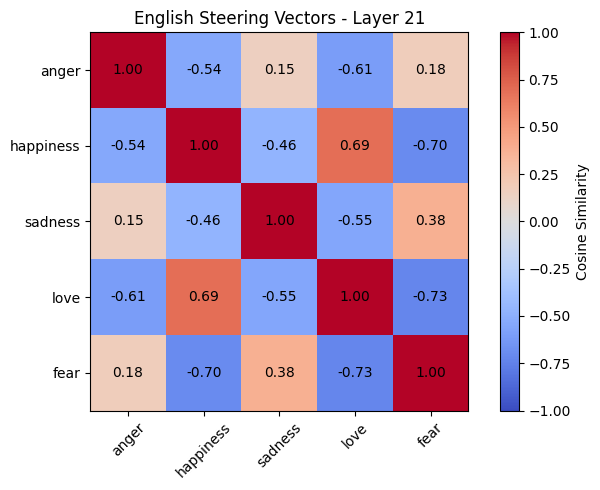

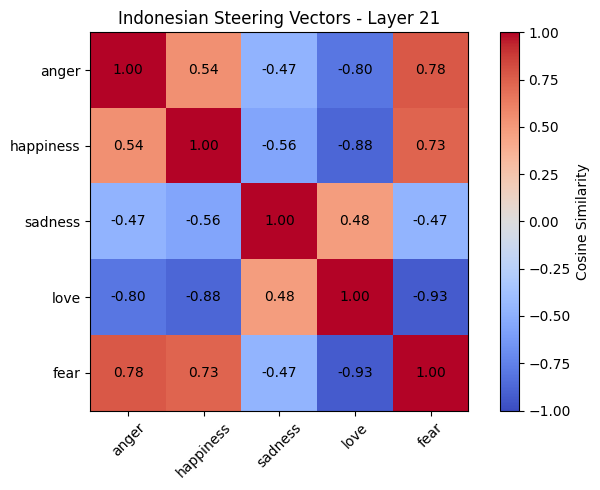

In [4]:


import matplotlib.pyplot as plt

emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']
layer_idx = 21

eng_cosine_matrix = analysis.build_cosine_matrix(steering_vector_eng, emotions, layer_idx)
id_cosine_matrix = analysis.build_cosine_matrix(steering_vector_id, emotions, layer_idx)

display(eng_cosine_matrix)
display(id_cosine_matrix)

plt.figure(figsize=(7, 5))
eng_plot = plt.imshow(eng_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(emotions)), emotions, rotation=45)
plt.yticks(range(len(emotions)), emotions)
plt.title('English Steering Vectors - Layer 21')
analysis.annotate_heatmap(plt.gca(), eng_cosine_matrix.values)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
id_plot = plt.imshow(id_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(emotions)), emotions, rotation=45)
plt.yticks(range(len(emotions)), emotions)
plt.title('Indonesian Steering Vectors - Layer 21')
analysis.annotate_heatmap(plt.gca(), id_cosine_matrix.values)
plt.tight_layout()
plt.show()

In [13]:
mantel_test_result = analysis.mantel_test(eng_cosine_matrix.values, id_cosine_matrix.values, num_permutations=1000)
print(f'Mantel Test Result: {mantel_test_result}')

Mantel Test Result: (np.float64(-0.26093655989224085), 0.453)


# Cosine Similarity across layers 

,emotion,layer,cosine_similarity
0,anger,0,0.262442
1,anger,1,0.986448
2,anger,2,0.968251
3,anger,3,0.919748
4,anger,4,0.855297


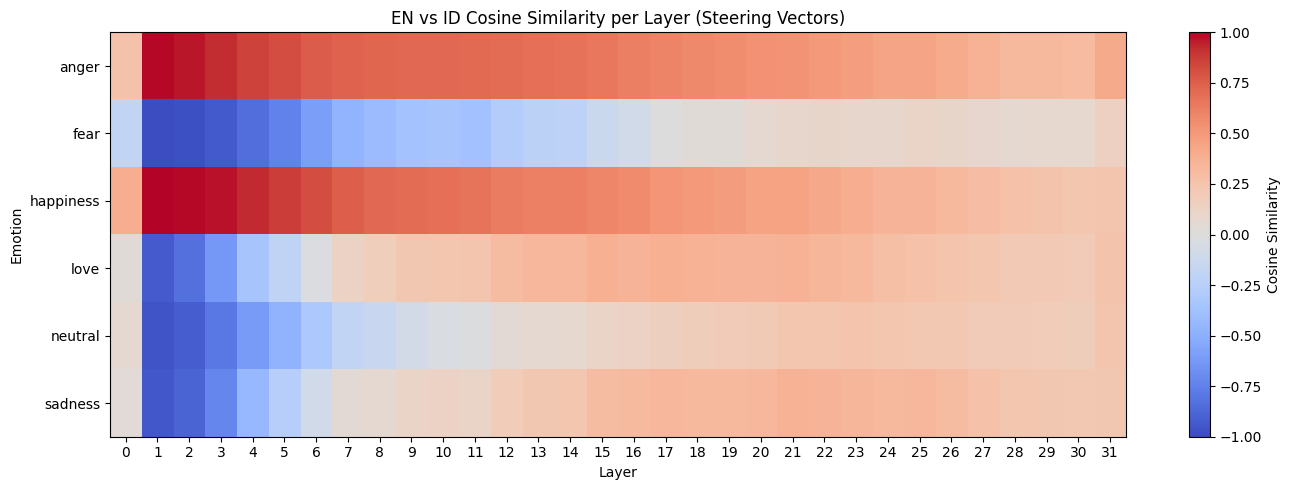

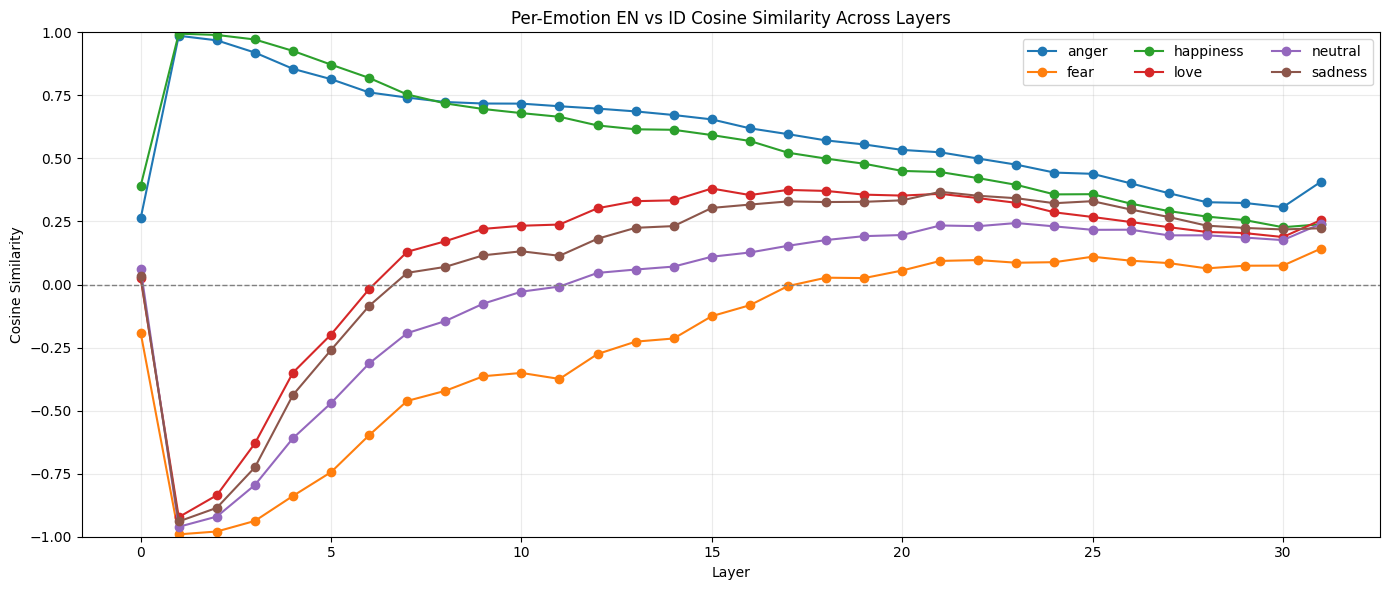

,mean,min,max
emotion,,,
anger,0.602258,0.262442,0.986448
happiness,0.563509,0.227269,0.994790
love,0.129181,-0.922400,0.380684
sadness,0.091719,-0.939441,0.367609
neutral,-0.029900,-0.960747,0.243885
fear,-0.220618,-0.990620,0.142518


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Cosine similarity per layer between EN and ID steering vectors for each emotion
emotions = ["anger", "happiness", "sadness", "love", "fear", "neutral"]
available_emotions = [
    e for e in emotions
    if e in steering_vector_eng and e in steering_vector_id
]

records = []
for emotion in available_emotions:
    en_vec = steering_vector_eng[emotion]
    id_vec = steering_vector_id[emotion]

    if en_vec.shape != id_vec.shape:
        raise ValueError(
            f"Shape mismatch for emotion '{emotion}': EN {en_vec.shape} vs ID {id_vec.shape}"
        )

    layer_sims = F.cosine_similarity(en_vec, id_vec, dim=1)
    for layer_idx, sim in enumerate(layer_sims.tolist()):
        records.append(
            {
                "emotion": emotion,
                "layer": layer_idx,
                "cosine_similarity": sim,
            }
        )

cosine_df = pd.DataFrame(records)
display(cosine_df.head())

# Pivot for heatmap-like matrix: rows = emotions, cols = layers
heatmap_df = cosine_df.pivot(index="emotion", columns="layer", values="cosine_similarity")

plt.figure(figsize=(14, 5))
plt.imshow(heatmap_df.values, aspect="auto", interpolation="nearest", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Cosine Similarity")
plt.yticks(ticks=np.arange(len(heatmap_df.index)), labels=heatmap_df.index)
plt.xticks(ticks=np.arange(len(heatmap_df.columns)), labels=heatmap_df.columns)
plt.xlabel("Layer")
plt.ylabel("Emotion")
plt.title("EN vs ID Cosine Similarity per Layer (Steering Vectors)")
plt.tight_layout()
plt.show()

# Line plot per emotion across layers
plt.figure(figsize=(14, 6))
for emotion in heatmap_df.index:
    plt.plot(heatmap_df.columns, heatmap_df.loc[emotion].values, marker="o", linewidth=1.5, label=emotion)

plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
plt.ylim(-1, 1)
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Per-Emotion EN vs ID Cosine Similarity Across Layers")
plt.legend(loc="best", ncol=3)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Optional summary table (mean/min/max similarity per emotion)
summary_df = (
    cosine_df.groupby("emotion")["cosine_similarity"]
    .agg(["mean", "min", "max"])
    .sort_values("mean", ascending=False)
)
display(summary_df)